
## Facebook Live Sellers in Thailand

### by Fariba Abasnejad & Soodabe Rahimi

In this project, the **CRISP-DM (Cross-Industry Standard Process for Data Mining)** methodology has been used.


https://www.sv-europe.com/crisp-dm-methodology/

### 1.Business Understanding

Goal: Analyze user engagement patterns (comments, reactions, shares) in response to content posted by fashion and cosmetics sellers on Facebook to identify effective sales and engagement strategies.


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2.Data Understanding

Understand data collection process :

ta Source: Facebook posts from 10 Live sellers in fashion and cosmetics (7050 instances, 11 features).

In [54]:
data = pd.read_csv('Live_20210128.csv')
data

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7045,7046,photo,9/24/2016 2:58,89,0,0,89,0,0,0,0,0,NaN,NaN,NaN,NaN
7046,7047,photo,9/23/2016 11:19,16,0,0,14,1,0,1,0,0,NaN,NaN,NaN,NaN
7047,7048,photo,9/21/2016 23:03,2,0,0,1,1,0,0,0,0,NaN,NaN,NaN,NaN
7048,7049,photo,9/20/2016 0:43,351,12,22,349,2,0,0,0,0,NaN,NaN,NaN,NaN


In [31]:
data.shape

(7050, 16)

Document Data Set Description (Meta Data) :

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   int64  
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(10), object(2)
memory

In [33]:
data.columns.tolist()

['status_id',
 'status_type',
 'status_published',
 'num_reactions',
 'num_comments',
 'num_shares',
 'num_likes',
 'num_loves',
 'num_wows',
 'num_hahas',
 'num_sads',
 'num_angrys',
 'Column1',
 'Column2',
 'Column3',
 'Column4']

Main Features (Variables) of the Data:

status_type: Type of post (video, photo, link, text status)

num_comments: Number of user comments under each post

num_shares: Number of times the post was shared by users

num_reactions: Total number of user reactions (such as like, love, wow, etc.)

num_likes / num_loves / num_wows / num_hahas / num_sads / num_angrys: Breakdown of each specific Facebook reaction

status_published: Date and time the post was published

video_id / status_id / message: Internal identifiers related to each post (usually dropped or summarized during analysis)

Check for missing values :

In [34]:
data.isnull().sum()

status_id              0
status_type            0
status_published       0
num_reactions          0
num_comments           0
num_shares             0
num_likes              0
num_loves              0
num_wows               0
num_hahas              0
num_sads               0
num_angrys             0
Column1             7050
Column2             7050
Column3             7050
Column4             7050
dtype: int64

In [35]:
# Count missing values in each column  
missing = data.isnull().sum()
missing = missing[missing > 0]

print("\n🔍 Columns with missing values:")
print(missing if not missing.empty else "There are no missing values.")



🔍 Columns with missing values:
Column1    7050
Column2    7050
Column3    7050
Column4    7050
dtype: int64


data analysis :

In [36]:
data.describe()

,status_id,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
count,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,0.0,0.0,0.0,0.0
mean,3525.500000,230.117163,224.356028,40.022553,215.043121,12.728652,1.289362,0.696454,0.243688,0.113191,NaN,NaN,NaN,NaN
std,2035.304031,462.625309,889.636820,131.599965,449.472357,39.972930,8.719650,3.957183,1.597156,0.726812,NaN,NaN,NaN,NaN
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,1763.250000,17.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,3525.500000,59.500000,4.000000,0.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
75%,5287.750000,219.000000,23.000000,4.000000,184.750000,3.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
max,7050.000000,4710.000000,20990.000000,3424.000000,4710.000000,657.000000,278.000000,157.000000,51.000000,31.000000,NaN,NaN,NaN,NaN


In [37]:
# Numeric columns
data_numeric = data.select_dtypes(include='number')

print("\n Statistical summary of numerical variables:")
print(data_numeric.describe())



 Statistical summary of numerical variables:
         status_id  num_reactions  num_comments   num_shares    num_likes  \
count  7050.000000    7050.000000   7050.000000  7050.000000  7050.000000   
mean   3525.500000     230.117163    224.356028    40.022553   215.043121   
std    2035.304031     462.625309    889.636820   131.599965   449.472357   
min       1.000000       0.000000      0.000000     0.000000     0.000000   
25%    1763.250000      17.000000      0.000000     0.000000    17.000000   
50%    3525.500000      59.500000      4.000000     0.000000    58.000000   
75%    5287.750000     219.000000     23.000000     4.000000   184.750000   
max    7050.000000    4710.000000  20990.000000  3424.000000  4710.000000   

         num_loves     num_wows    num_hahas     num_sads   num_angrys  \
count  7050.000000  7050.000000  7050.000000  7050.000000  7050.000000   
mean     12.728652     1.289362     0.696454     0.243688     0.113191   
std      39.972930     8.719650     3.

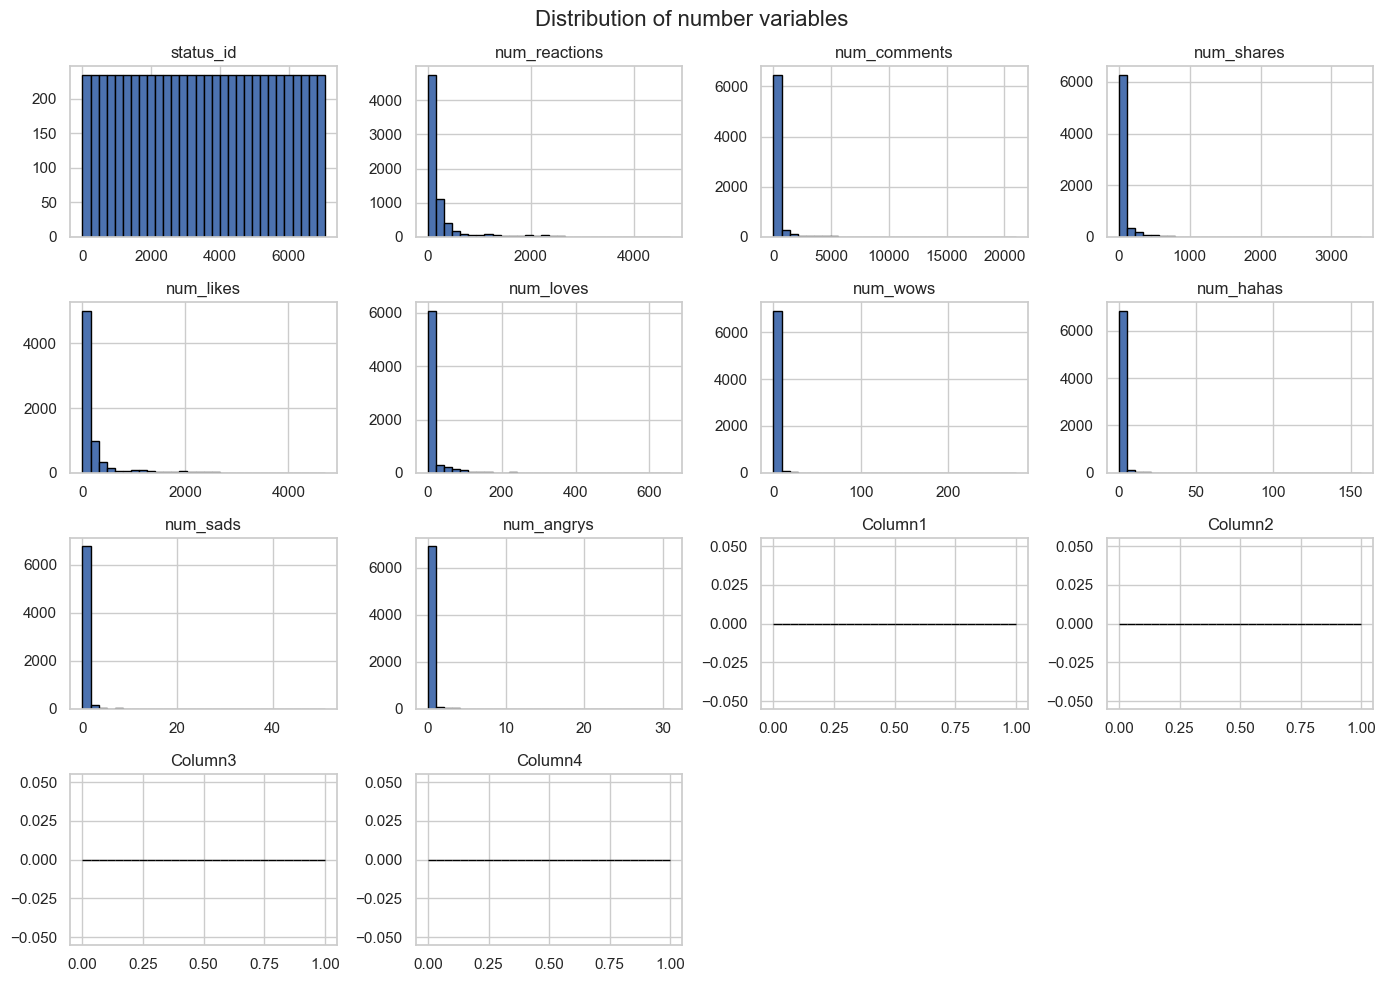

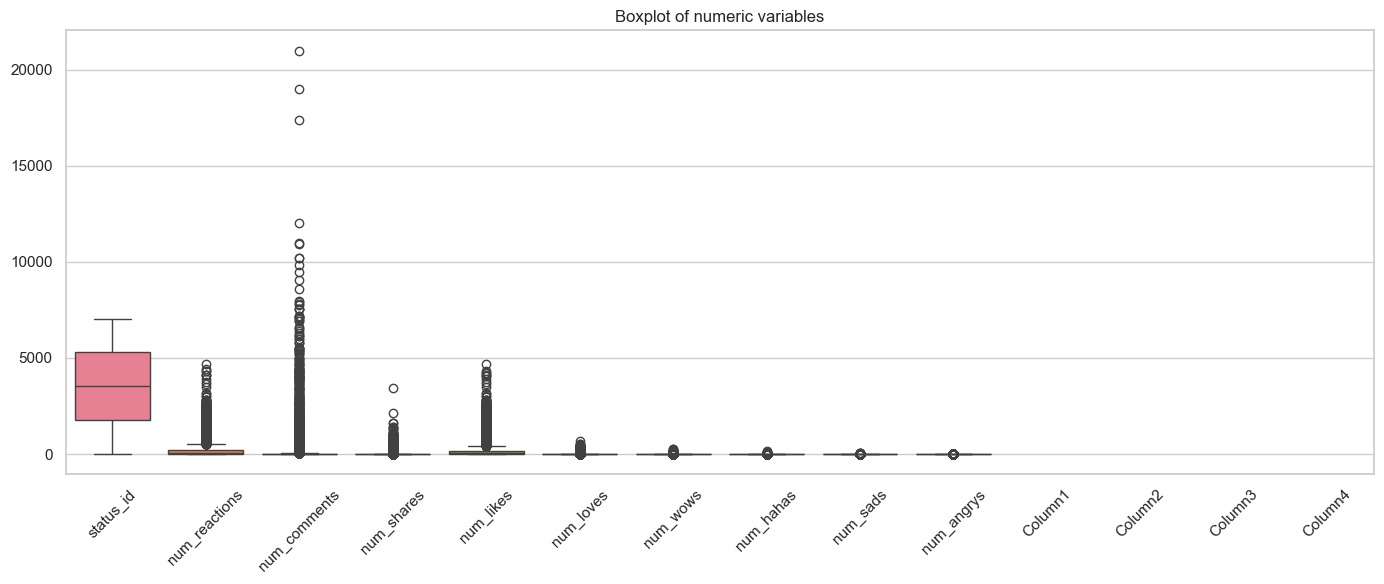

In [38]:

sns.set(style="whitegrid")

# Histogram
data_numeric.hist(figsize=(14, 10), bins=30, edgecolor='black')
plt.suptitle("Distribution of number variables", fontsize=16)
plt.tight_layout()
plt.show()

# Boxplot to compare outliers
plt.figure(figsize=(14, 6))
sns.boxplot(data=data_numeric)
plt.xticks(rotation=45)
plt.title("Boxplot of numeric variables")
plt.tight_layout()
plt.show()


C:\Users\Pc Dayan\AppData\Local\Temp\ipykernel_3780\2181076060.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='status_type', data=data, order=data['status_type'].value_counts().index, palette='Set2')


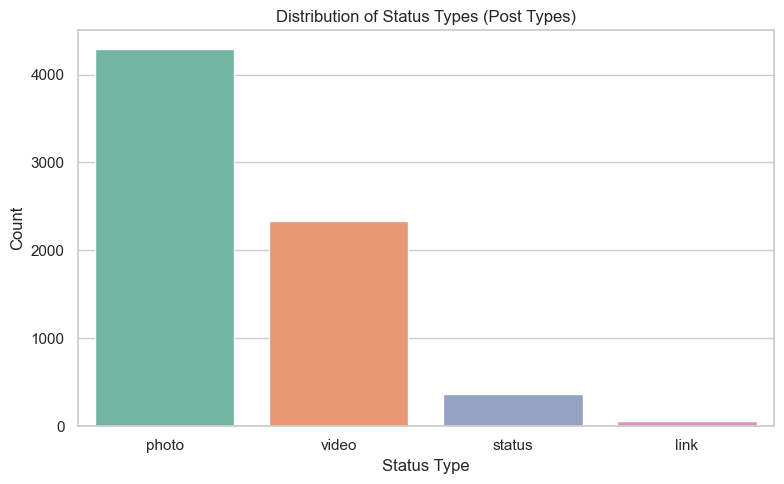

📊 Percentage of each post type:

status_type
photo     60.82
video     33.11
status     5.18
link       0.89
Name: proportion, dtype: float64


In [39]:
sns.set(style="whitegrid")

# Post type count chart
plt.figure(figsize=(8, 5))
sns.countplot(x='status_type', data=data, order=data['status_type'].value_counts().index, palette='Set2')
plt.title("Distribution of Status Types (Post Types)")
plt.xlabel("Status Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Frequency percentage of each post type
status_percent = data['status_type'].value_counts(normalize=True) * 100
print("📊 Percentage of each post type:\n")
print(status_percent.round(2))


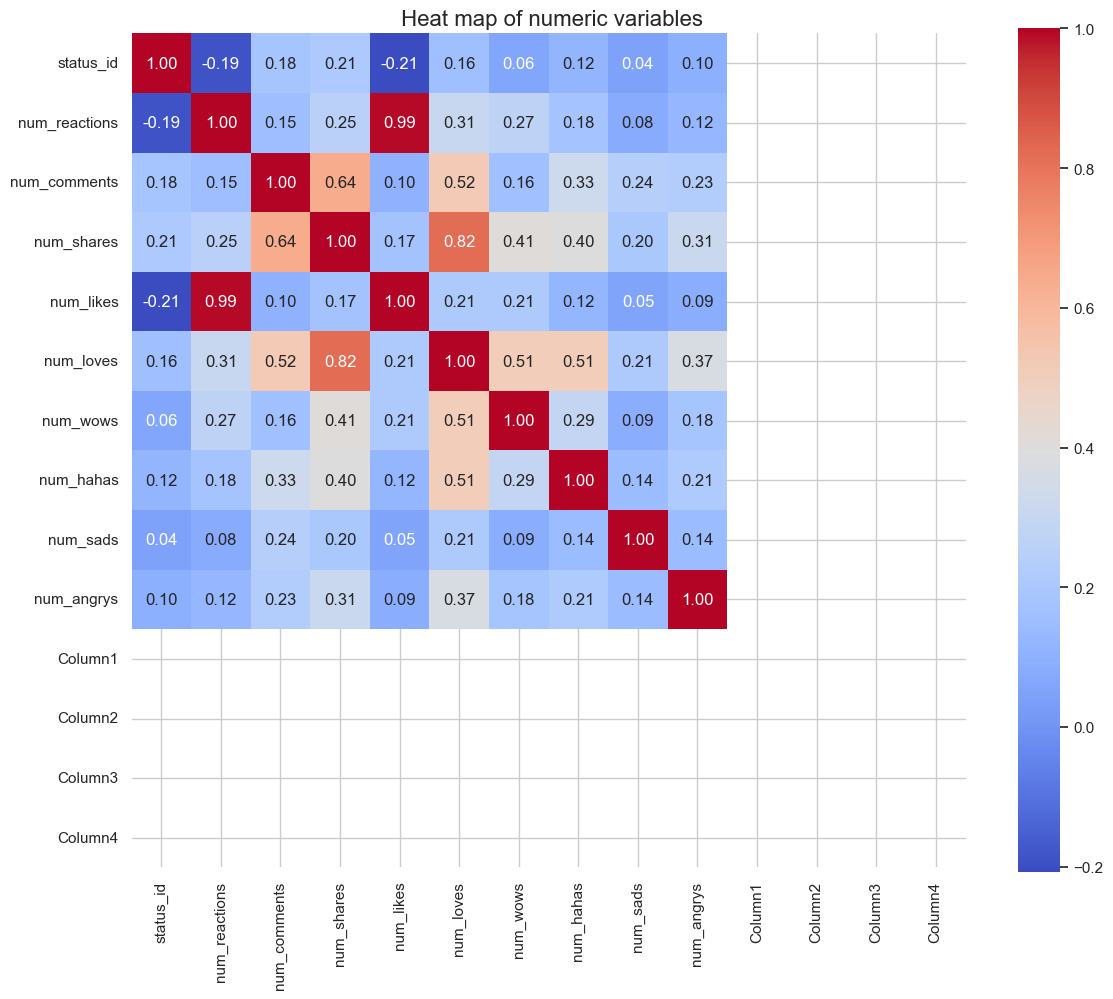

In [40]:
#Correlation
corr_matrix = data_numeric.corr()

# Heat map
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title(" Heat map of numeric variables", fontsize=16)
plt.tight_layout()
plt.show()


### 3.Data Preparation

In [41]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

def preprocess_data(data):
    data = data.copy()

    #1. Remove completely null columns
    data.dropna(axis=1, how='all', inplace=True)
    
    #2. Remove non-numeric columns that are not useful for unsupervised algorithms
    useless_cols = []
    for col in data.columns:
        if data[col].dtype == 'object':
            if 'id' in col.lower() or 'message' in col.lower() or 'date' in col.lower():
                useless_cols.append(col)
    data.drop(columns=useless_cols, inplace=True)

    #3. Select only numeric columns for analysis
    numeric_data = data.select_dtypes(include='number')

    #4. Replace NaN with the average of each column
    imputer = SimpleImputer(strategy='mean')
    X_imputed = imputer.fit_transform(numeric_data)

   # 5.Normalization
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(numeric_data)

    # 6.Convert back to dataframe to preserve column names
    X_scaled_data = pd.DataFrame(X_scaled, columns=numeric_data.columns)

    return X_scaled_data, data


In [42]:
X_scaled, cleaned_data = preprocess_data(data)
cleaned_data.to_csv("cleaned_data.csv ", index=False)

In [43]:

# Load cleaned dataset
df = pd.read_csv("cleaned_data.csv")

### 4.Modeling

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
# --- Feature Selection --- #
features = [
    'num_reactions', 'num_comments', 'num_shares',
    'num_likes', 'num_loves', 'num_wows',
    'num_hahas', 'num_sads', 'num_angrys'
]
X = df[features]

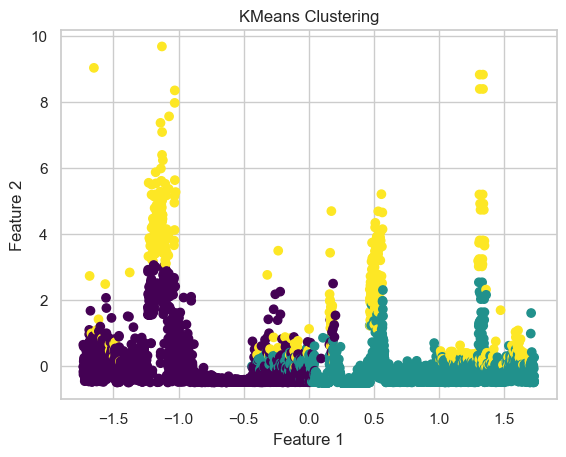

In [57]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

data['kmeans_cluster'] = kmeans_labels

plt.scatter(X_scaled.iloc[:, 0], X_scaled.iloc[:, 1], c=kmeans_labels, cmap='viridis')
plt.title("KMeans Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


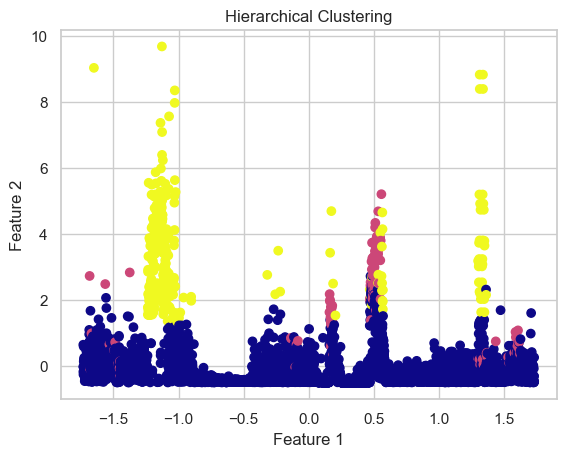

In [59]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X_scaled)

df['agg_cluster'] = agg_labels

plt.scatter(X_scaled.iloc[:, 0], X_scaled.iloc[:, 1], c=agg_labels, cmap='plasma')
plt.title("Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


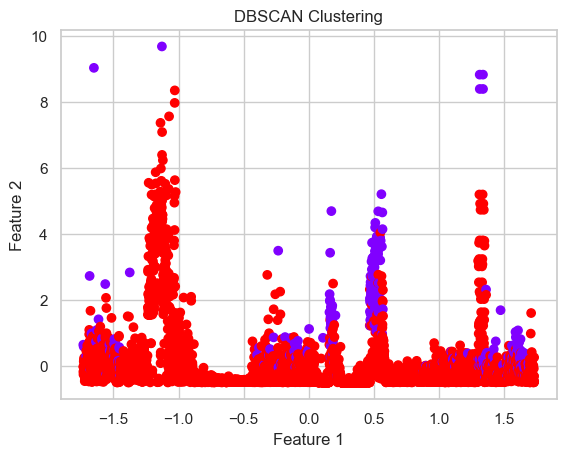

In [48]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['dbscan_cluster'] = dbscan_labels

plt.scatter(X_scaled.iloc[:, 0], X_scaled.iloc[:, 1], c=dbscan_labels, cmap='rainbow')
plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


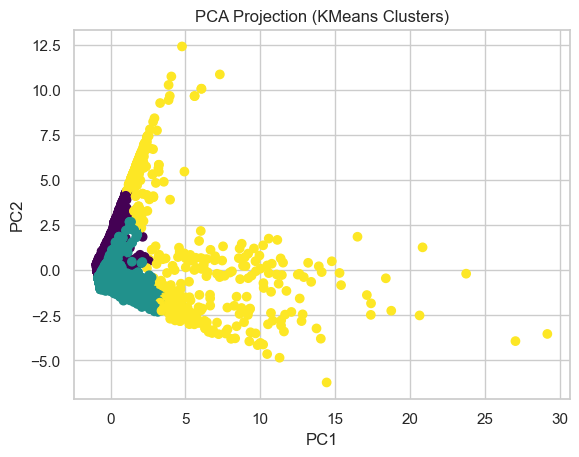

In [49]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis')
plt.title("PCA Projection (KMeans Clusters)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


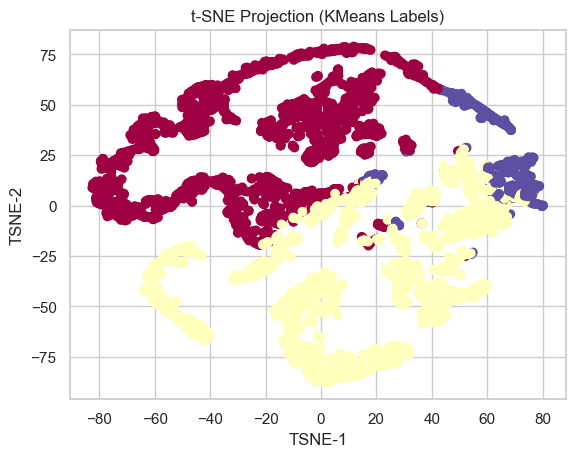

In [50]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels, cmap='Spectral')
plt.title("t-SNE Projection (KMeans Labels)")
plt.xlabel("TSNE-1") 
plt.ylabel("TSNE-2")
plt.show()


In [51]:

# --- KMeans Modeling --- #
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_score = silhouette_score(X_scaled, kmeans_labels)
print(f"KMeans Silhouette Score: {kmeans_score:.2f}")

# --- GMM Modeling --- #
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)
gmm_score = silhouette_score(X_scaled, gmm_labels)
print(f"GMM Silhouette Score: {gmm_score:.2f}")

# --- Agglomerative Clustering --- #
agg = AgglomerativeClustering(n_clusters=4)
agg_labels = agg.fit_predict(X_scaled)
agg_score = silhouette_score(X_scaled, agg_labels)
print(f"Agglomerative Clustering Silhouette Score: {agg_score:.2f}")

# --- DBSCAN --- #
dbscan = DBSCAN(eps=1.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
if len(set(dbscan_labels)) > 1:
    dbscan_score = silhouette_score(X_scaled, dbscan_labels)
    print(f"DBSCAN Silhouette Score: {dbscan_score:.2f}")
else:
    print("DBSCAN failed to find clusters")





KMeans Silhouette Score: 0.37
GMM Silhouette Score: 0.23
Agglomerative Clustering Silhouette Score: 0.54
DBSCAN Silhouette Score: 0.22


In [52]:
# --- Add Cluster to DataFrame --- #
df['cluster'] = kmeans_labels

# --- Cluster Analysis --- #
cluster_summary = df.groupby('cluster')[features].mean()
print("\nCluster Feature Means:\n", cluster_summary)

# --- PCA for Visualization --- #
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)
df['pca1'] = pca_components[:, 0]
df['pca2'] = pca_components[:, 1]




Cluster Feature Means:
          num_reactions  num_comments  num_shares    num_likes   num_loves  \
cluster                                                                     
0           125.059506     21.341267    3.039869   121.670931    2.723594   
1           108.159948    231.411480   46.478878    92.813286   13.655272   
2          1849.000000     61.939058   11.537396  1843.315789    3.113573   
3           877.127753   3392.136564  544.696035   677.828194  163.497797   

          num_wows  num_hahas  num_sads  num_angrys  
cluster                                              
0         0.420708   0.093722  0.129426    0.015472  
1         0.728475   0.667849  0.188004    0.107062  
2         2.351801   0.188366  0.024931    0.005540  
3        20.123348  10.819383  3.044053    1.814978  


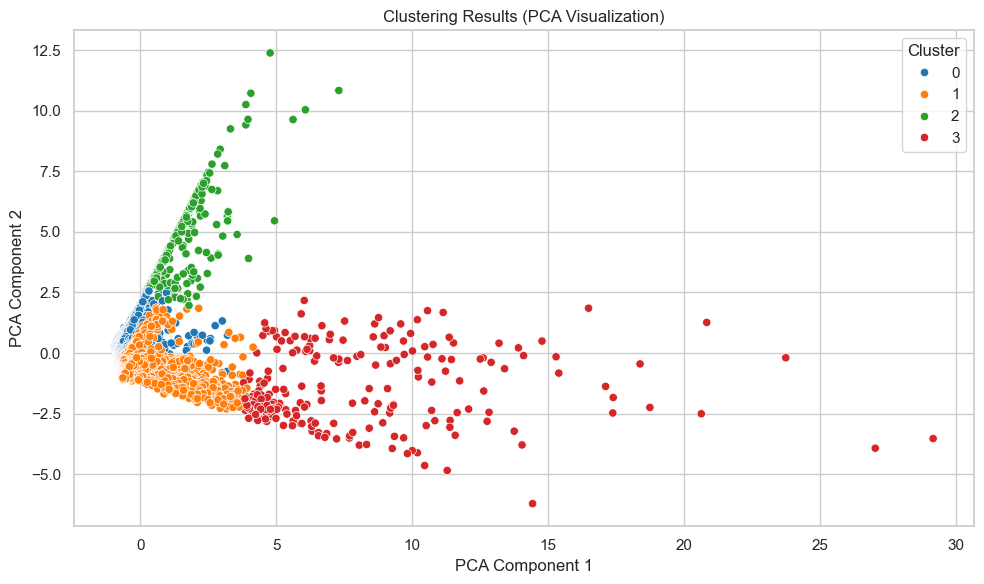

In [60]:
# --- Visualization --- #
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='cluster', palette='tab10')
plt.title("Clustering Results (PCA Visualization)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

### 5.Evaluation

In the evaluation phase of this project, we assessed the quality of the clustering results using the Silhouette Score metric. This metric quantifies how well each data point fits within its assigned cluster compared to other clusters. A higher Silhouette Score indicates better-defined clusters.

We applied and compared the following clustering algorithms:

KMeans: Silhouette Score = 0.37

Gaussian Mixture Model (GMM): Silhouette Score = 0.23

Agglomerative Clustering: Silhouette Score = 0.54

DBSCAN: Silhouette Score = 0.22

Among all models, Agglomerative Clustering achieved the highest Silhouette Score of 0.54, suggesting that it produced the most cohesive and well-separated clusters.

In addition to the quantitative evaluation, we also conducted a qualitative analysis by examining the mean values of key features within each cluster. The clusters revealed distinct behavioral patterns in terms of reactions, comments, and shares, confirming that the clustering results are meaningful and interpretable.

Based on both quantitative and qualitative assessments, Agglomerative Clustering was selected as the best-performing model for this project.



### 6.Deployment

To deploy clustering results, the trained model can be integrated into an API service using Python libraries such as Flask or FastAPI. This service enables real-time cluster prediction on new incoming data. For better management and deployment, tools like Docker are useful for containerizing the model, and cloud platforms like AWS or Azure provide reliable hosting. Additionally, interactive dashboards for visualizing clustering outcomes can be built using libraries such as Streamlit or Dash if needed.